In [1]:
#Medical Insurance Cost Prediction using Decision Random Forest

#Author: Manikandaprabhu.S  
#Objective: To build a Random Forest Regression model to predict medical insurance costs based on demographic and health-related features.

In [2]:
## 1. Importing Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
## 2. Loading the Dataset
dataset = pd.read_csv("insurance_pre.csv")
pd.options.display.max_rows = 10
dataset

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830
1334,18,female,31.920,0,no,2205.98080
1335,18,female,36.850,0,no,1629.83350
1336,21,female,25.800,0,no,2007.94500


In [4]:
## 3. Data Preprocessing (Handling Categorical Variables)
data = pd.get_dummies(dataset,dtype=int)
data

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes
0,19,27.900,0,16884.92400,1,0,0,1
1,18,33.770,1,1725.55230,0,1,1,0
2,28,33.000,3,4449.46200,0,1,1,0
3,33,22.705,0,21984.47061,0,1,1,0
4,32,28.880,0,3866.85520,0,1,1,0
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,0,1,1,0
1334,18,31.920,0,2205.98080,1,0,1,0
1335,18,36.850,0,1629.83350,1,0,1,0
1336,21,25.800,0,2007.94500,1,0,1,0


In [5]:
## 4. Exploratory Data Inspection
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         1338 non-null   int64  
 1   bmi         1338 non-null   float64
 2   children    1338 non-null   int64  
 3   charges     1338 non-null   float64
 4   sex_female  1338 non-null   int64  
 5   sex_male    1338 non-null   int64  
 6   smoker_no   1338 non-null   int64  
 7   smoker_yes  1338 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 83.8 KB


In [6]:
data.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_female', 'sex_male',
       'smoker_no', 'smoker_yes'],
      dtype='object')

In [7]:
## 5. Preparing Features and Target Variable
Features = data[['age', 'bmi', 'children','sex_male','smoker_yes']]
Target = data[['charges']].values.ravel()
Features

,age,bmi,children,sex_male,smoker_yes
0,19,27.900,0,0,1
1,18,33.770,1,1,0
2,28,33.000,3,1,0
3,33,22.705,0,1,0
4,32,28.880,0,1,0
...,...,...,...,...,...
1333,50,30.970,3,1,0
1334,18,31.920,0,0,0
1335,18,36.850,0,0,0
1336,21,25.800,0,0,0


In [8]:
## 6. Splitting Dataset into Training and Testing Sets
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(Features,Target,test_size=1/3,random_state=0)
x_train

,age,bmi,children,sex_male,smoker_yes
482,18,31.35,0,0,0
338,50,32.30,1,1,1
356,46,43.89,3,1,0
869,25,24.30,3,0,0
182,22,19.95,3,1,0
...,...,...,...,...,...
763,27,26.03,0,1,0
835,42,35.97,2,1,0
1216,40,25.08,0,1,0
559,19,35.53,0,1,0


In [9]:
## 7. Feature Scaling (Important for Random Forest)

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)
x_test


array([[ 0.89108031, -0.07576237, -0.0755796 ,  1.01127431, -0.49929923],
       [ 0.5336223 , -0.21009861, -0.0755796 , -0.98885138, -0.49929923],
       [ 0.6051139 ,  1.60182214,  0.75672907,  1.01127431,  2.00280702],
       ...,
       [-1.46814257,  0.65256665,  0.75672907, -0.98885138,  2.00280702],
       [-0.82471815,  0.37742013,  1.58903774,  1.01127431, -0.49929923],
       [ 0.89108031,  1.24817794,  0.75672907, -0.98885138, -0.49929923]],
      shape=(446, 5))

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {'criterion': ['squared_error', 'absolute_error'],'max_features': ['sqrt', 'log2'],'n_estimators': [10, 100]}

grid = GridSearchCV(RandomForestRegressor(random_state=0),param_grid,refit=True,verbose=3,n_jobs=-1)

grid.fit(x_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,estimator,RandomForestR...andom_state=0)
,param_grid,"{'criterion': ['squared_error', 'absolute_error'], 'max_features': ['sqrt', 'log2'], 'n_estimators': [10, 100]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [11]:
## 9. Hyperparameter Results Analysis

re=grid.cv_results_
print("The R_score value for best parameter {}:".format(grid.best_params_))

The R_score value for best parameter {'criterion': 'squared_error', 'max_features': 'sqrt', 'n_estimators': 100}:


In [12]:
table=pd.DataFrame.from_dict(re)
table

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_features,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.055716,0.007741,0.005843,0.001791,squared_error,sqrt,10,"{'criterion': 'squared_error', 'max_features':...",0.758786,0.757606,0.809196,0.807250,0.750450,0.776658,0.025938,7
1,0.453942,0.022836,0.026104,0.002129,squared_error,sqrt,100,"{'criterion': 'squared_error', 'max_features':...",0.801790,0.765004,0.835962,0.828515,0.762151,0.798684,0.030849,1
2,0.048296,0.009930,0.005247,0.000994,squared_error,log2,10,"{'criterion': 'squared_error', 'max_features':...",0.758786,0.757606,0.809196,0.807250,0.750450,0.776658,0.025938,7
3,0.492437,0.037907,0.027247,0.008048,squared_error,log2,100,"{'criterion': 'squared_error', 'max_features':...",0.801790,0.765004,0.835962,0.828515,0.762151,0.798684,0.030849,1
4,0.138174,0.016050,0.005125,0.000941,absolute_error,sqrt,10,"{'criterion': 'absolute_error', 'max_features'...",0.785768,0.776698,0.804770,0.804487,0.746092,0.783563,0.021650,5
5,1.123349,0.039934,0.023831,0.002207,absolute_error,sqrt,100,"{'criterion': 'absolute_error', 'max_features'...",0.798504,0.771337,0.835841,0.814641,0.762294,0.796524,0.027144,3
6,0.124165,0.008263,0.004359,0.001430,absolute_error,log2,10,"{'criterion': 'absolute_error', 'max_features'...",0.785768,0.776698,0.804770,0.804487,0.746092,0.783563,0.021650,5
7,1.130744,0.032475,0.026445,0.002720,absolute_error,log2,100,"{'criterion': 'absolute_error', 'max_features'...",0.798504,0.771337,0.835841,0.814641,0.762294,0.796524,0.027144,3


In [13]:
## 10. Model Evaluation
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

y_pred = grid.predict(x_test) 

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred)
n = x_test.shape[0]  
p = x_test.shape[1]   
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("R2 Score:", r2)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("Mean Absolute Error:", mae)
print("Adjusted R2 Score:", adjusted_r2)

R2 Score: 0.8721406908163178
Mean Squared Error: 20500347.995001353
Root Mean Squared Error: 4527.730998524687
Mean Absolute Error: 2616.9959991628753
Adjusted R2 Score: 0.8706877441210488


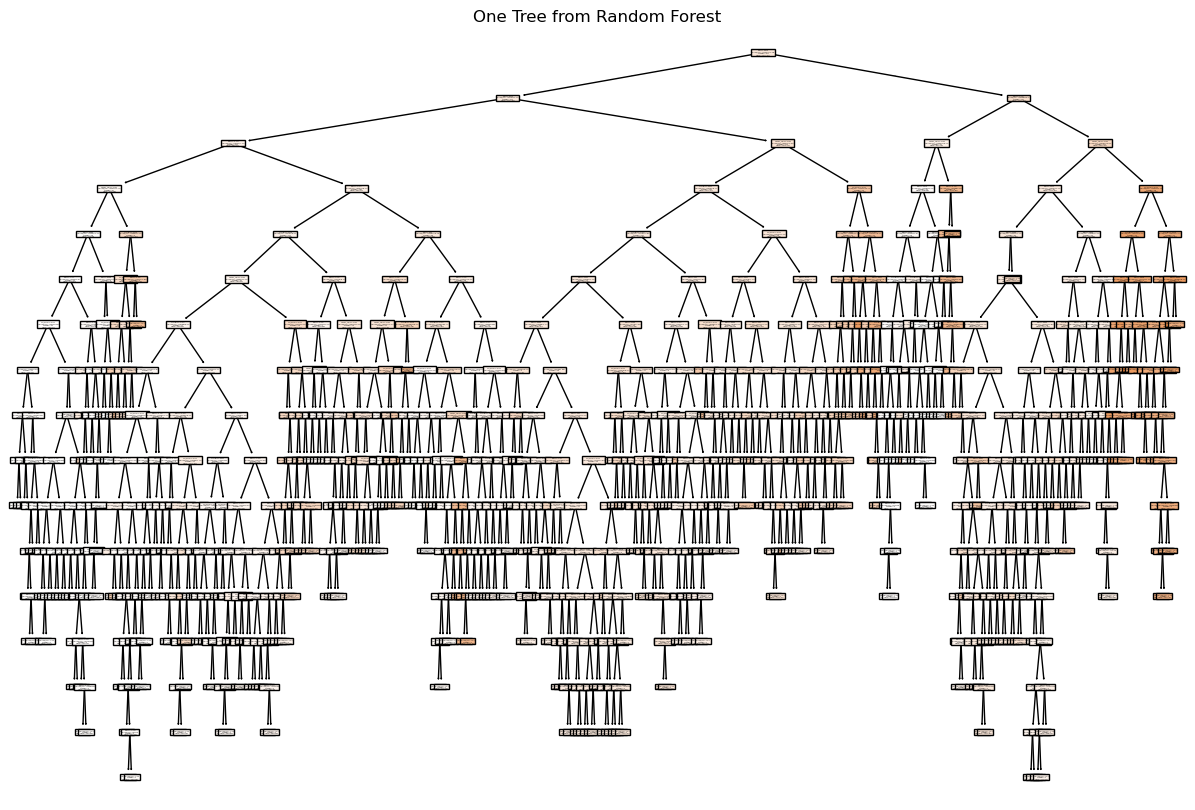

In [18]:
## 11. Visualizing Model Performance
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Get best model
best_model = grid.best_estimator_

# Get feature names
feature_names = ['age', 'bmi', 'children', 'sex_male', 'smoker_yes']

# Plot one tree
plt.figure(figsize=(15, 10))
plot_tree(best_model.estimators_[0],filled=True,feature_names=feature_names)

plt.title("One Tree from Random Forest")
plt.show()

In [15]:
## 12. Saving the Trained Model and Scaler
best_model = grid.best_estimator_

import pickle

# Save scaler
pickle.dump(sc, open("scaler_RF.pkl", "wb"))

# Save model
pickle.dump(best_model, open("Finalized_RF_model.sav", "wb"))

In [16]:
## Conclusion:

#- Implemented Random Forest Regression to predict medical insurance costs.
#- The ensemble approach improved prediction accuracy compared to a single Decision Tree.
#- Model effectively handles non-linear relationships without requiring feature scaling.
#- Achieved strong performance based on R², MSE, and RMSE metrics.
#- Demonstrates the advantage of ensemble learning in reducing overfitting and improving generalization.